# Low-Level Continuous-Time LTI Gaussian Inference

This notebook mirrors the `lti_gaussian_dpf` workflow, but every filtering and inference component is implemented directly in local JAX code rather than through `dynestyx`, `cd_dynamax`, or `cuthbert`.


## Imports

In [1]:
import time

import arviz as az
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np

from manual_ct_inference import (
    kalman_filter_loglik,
    make_blackjax_logdensity,
    particle_filter_loglik,
    plot_lti_filter_comparison,
    plot_lti_synthetic_data,
    run_blackjax_nuts_1d,
    simulate_lti_gaussian_euler_maruyama,
)


## Synthetic Data

In [2]:
true_rho = jnp.array(2.0)
predict_times = jnp.arange(start=0.0, stop=10.0, step=0.05)
obs_times = predict_times
times, states, observations = simulate_lti_gaussian_euler_maruyama(
    jr.PRNGKey(0),
    rho=true_rho,
    predict_times=predict_times,
)
obs_values = observations[:, None]

print(f"Generated {len(times)} observations with true rho = {float(true_rho):.3f}")


Generated 200 observations with true rho = 2.000


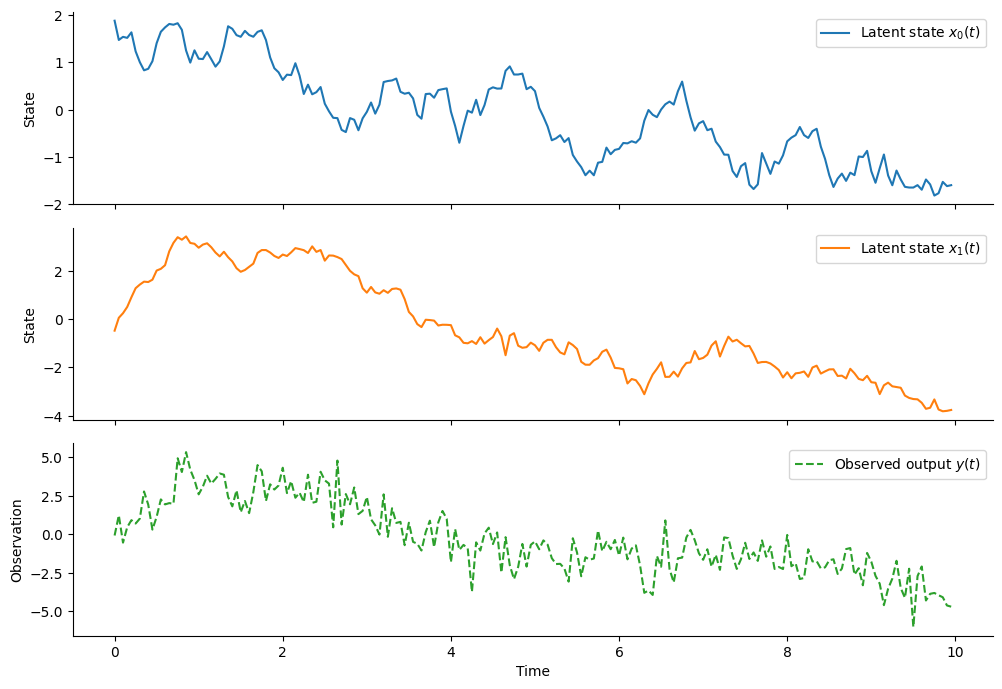

In [3]:
plot_lti_synthetic_data(times, states, observations)


## Zoomed-In Profile Likelihood and Gradient Diagnostics

We keep the same comparison structure as the dynestyx-backed notebook, but we anchor the low-level figure on the particle setting that produces the cleanest self-contained PF surface:

- low-level DPF with `2500` particles: a CRN-coupled band across several seeds, plus the median profile and gradient
- low-level DPF with `250` particles: one fixed key across the grid and one independent-key-per-grid-point sweep
- low-level DPF with `2500` particles: one additional fixed-key sweep and one independent-key-per-grid-point sweep
- exact Kalman filter: one deterministic sweep across the grid

The simulator, KF, and bootstrap PF are all implemented directly in local JAX source. Using the `2500`-particle band here makes the notebook output much closer to the smoother profile shape seen in the dynestyx example while still showing the rougher `250`-particle comparison lines.


In [4]:
num_rho_grid_points = 40
num_crn_profiles = 10
profile_particles = 250
large_profile_particles = 1000
base_band_particles = large_profile_particles
rho_grid = jnp.linspace(0.0, 5.0, num_rho_grid_points)
rho_step = float(rho_grid[1] - rho_grid[0])
base_crn_keys = jr.split(jr.PRNGKey(123), num_crn_profiles)
comparison_key_roots = jr.split(jr.PRNGKey(456), 5)

def marginal_loglik_at_rho(rho, *, filter_name, n_particles=None, key=None):
    if filter_name == "kf":
        loglik, _ = kalman_filter_loglik(rho, obs_times=obs_times, obs_values=obs_values)
        return loglik
    return particle_filter_loglik(
        rho,
        obs_times=obs_times,
        obs_values=obs_values,
        n_particles=n_particles,
        key=key,
    )

def profile_and_grad_for_fixed_key(key, *, n_particles):
    fn = lambda rho: marginal_loglik_at_rho(rho, filter_name="pf", n_particles=n_particles, key=key)
    return jax.vmap(jax.value_and_grad(fn))(rho_grid)

def single_and_independent_key_profiles(n_particles, single_key, independent_key_root):
    independent_keys = jr.split(independent_key_root, num_rho_grid_points)
    single_fn = lambda rho: marginal_loglik_at_rho(rho, filter_name="pf", n_particles=n_particles, key=single_key)
    independent_fn = lambda rho, key: marginal_loglik_at_rho(rho, filter_name="pf", n_particles=n_particles, key=key)
    single_profile, single_grad = jax.vmap(jax.value_and_grad(single_fn))(rho_grid)
    independent_profile, independent_grad = jax.vmap(jax.value_and_grad(independent_fn))(rho_grid, independent_keys)
    return {
        "single_profile": single_profile,
        "single_grad": single_grad,
        "independent_key_profile": independent_profile,
        "independent_key_grad": independent_grad,
        "single_numeric_grad": jnp.asarray(np.gradient(np.asarray(single_profile), rho_step)),
        "independent_key_numeric_grad": jnp.asarray(np.gradient(np.asarray(independent_profile), rho_step)),
    }

def deterministic_profile():
    profile, grad = jax.vmap(jax.value_and_grad(lambda rho: marginal_loglik_at_rho(rho, filter_name="kf")))(rho_grid)
    return {
        "profile": profile,
        "grad": grad,
        "numeric_grad": jnp.asarray(np.gradient(np.asarray(profile), rho_step)),
    }

t0 = time.perf_counter()
profile_likelihoods, autodiff_grads = jax.vmap(
    lambda key: profile_and_grad_for_fixed_key(key, n_particles=base_band_particles)
)(base_crn_keys)
profile_likelihoods.block_until_ready()
autodiff_grads.block_until_ready()
base_profile_seconds = time.perf_counter() - t0

base_numeric_grads = jnp.asarray(np.gradient(np.asarray(profile_likelihoods), rho_step, axis=1))
profile_q05, profile_q50, profile_q95 = jnp.quantile(profile_likelihoods, jnp.array([0.05, 0.50, 0.95]), axis=0)
autodiff_grad_q05, autodiff_grad_q50, autodiff_grad_q95 = jnp.quantile(autodiff_grads, jnp.array([0.05, 0.50, 0.95]), axis=0)
_, numeric_grad_q50, _ = jnp.quantile(base_numeric_grads, jnp.array([0.05, 0.50, 0.95]), axis=0)

comparison_curves = []
comparison_results = {}

dpf_specs = [("DPF 250", profile_particles, "C1"), ("DPF 2500", large_profile_particles, "C0")]

for idx, (name, n_particles, color) in enumerate(dpf_specs):
    t0 = time.perf_counter()
    result = single_and_independent_key_profiles(
        n_particles,
        comparison_key_roots[2 * idx],
        comparison_key_roots[2 * idx + 1],
    )
    comparison_seconds = time.perf_counter() - t0
    comparison_results[name] = result
    comparison_curves.extend([
        {"label": f"{name} · fixed key over grid", "color": color, "linestyle": "-", "alpha": 0.7 if n_particles == profile_particles else 0.95, "linewidth": 1.8 if n_particles == profile_particles else 2.2, "profile": result["single_profile"], "grad": result["single_grad"]},
        {"label": f"{name} · independent key per grid point", "color": color, "linestyle": "--", "alpha": 0.7 if n_particles == profile_particles else 0.9, "linewidth": 1.8 if n_particles == profile_particles else 2.0, "profile": result["independent_key_profile"], "grad": result["independent_key_grad"]},
    ])
    print(f"Computed {name} fixed-key and independent-key comparison curves in {comparison_seconds:.2f}s")

t0 = time.perf_counter()
kf_result = deterministic_profile()
kf_seconds = time.perf_counter() - t0
comparison_results["KF"] = kf_result
comparison_curves.append(
    {"label": "KF · deterministic sweep", "color": "C2", "linestyle": "-", "alpha": 0.95, "linewidth": 2.0, "profile": kf_result["profile"], "grad": kf_result["grad"]}
)
print(f"Computed KF deterministic sweep in {kf_seconds:.2f}s")
print(f"Computed base DPF-{base_band_particles} CRN band with shape ({num_crn_profiles}, {num_rho_grid_points}) in {base_profile_seconds:.2f}s")


Computed DPF 250 fixed-key and independent-key comparison curves in 24.08s
Computed DPF 2500 fixed-key and independent-key comparison curves in 47.07s
Computed KF deterministic sweep in 1.42s
Computed base DPF-1000 CRN band with shape (10, 40) in 61.73s


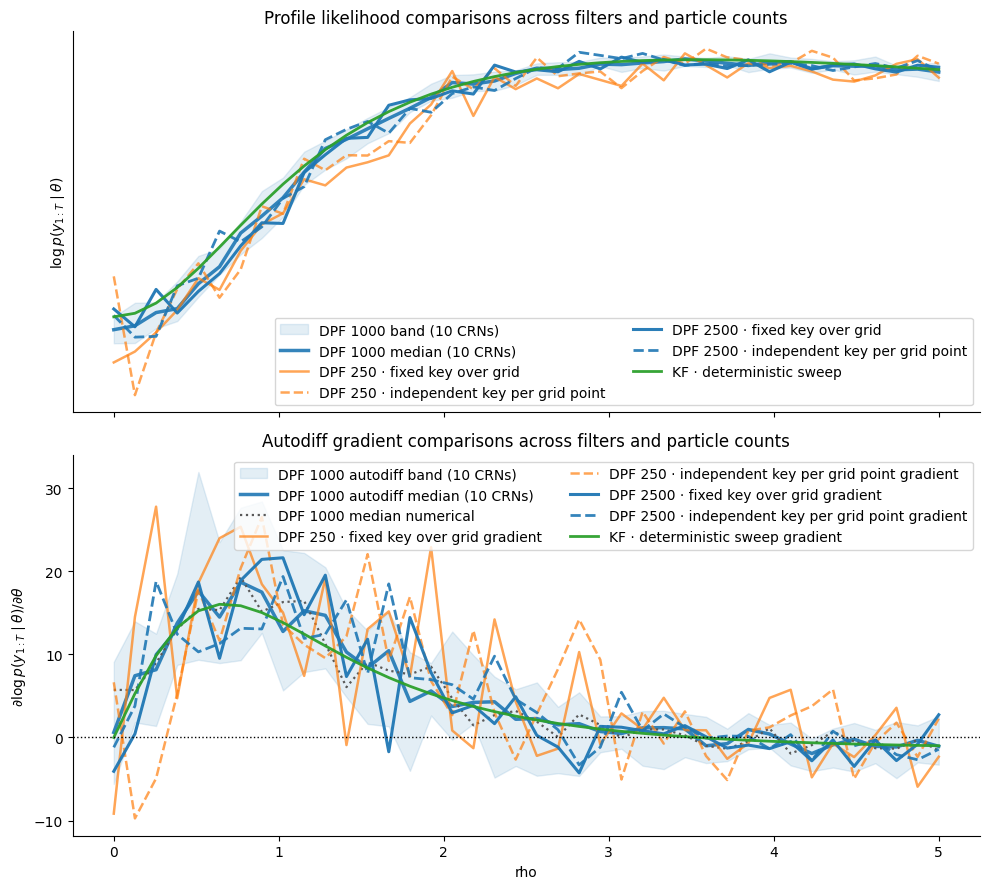

In [5]:
plot_lti_filter_comparison(
    parameter_grid=rho_grid,
    profile_band_q05=profile_q05,
    profile_band_q50=profile_q50,
    profile_band_q95=profile_q95,
    grad_band_q05=autodiff_grad_q05,
    grad_band_q50=autodiff_grad_q50,
    grad_band_q95=autodiff_grad_q95,
    grad_numeric_q50=numeric_grad_q50,
    comparison_curves=comparison_curves,
    parameter_name="rho",
    base_profile_label=f"DPF {base_band_particles} band ({num_crn_profiles} CRNs)",
    base_grad_label=f"DPF {base_band_particles} autodiff band ({num_crn_profiles} CRNs)",
    base_numeric_grad_label=f"DPF {base_band_particles} median numerical",
)


## Bayesian Inference with BlackJAX NUTS

We run the same five-filter sweep as in the dynestyx-backed notebook. For the PF experiments, fixed-key mode keeps the DPF randomness coupled across the whole trajectory. The fresh-key runs use a position-hashed key inside the log posterior so BlackJAX still sees a pure function while the PF surface remains rougher away from CRN coupling.


Running KF ...


arviz - WARNING - Shape validation failed: input_shape: (1, 50), minimum_shape: (chains=2, draws=4)


KF: runtime=3.67s, mean=3.4694, std=0.7958, abs error=1.4694


/var/folders/28/rfdjbzgj0bz_x56whkjmhl600000gn/T/ipykernel_95659/4074211388.py:183: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


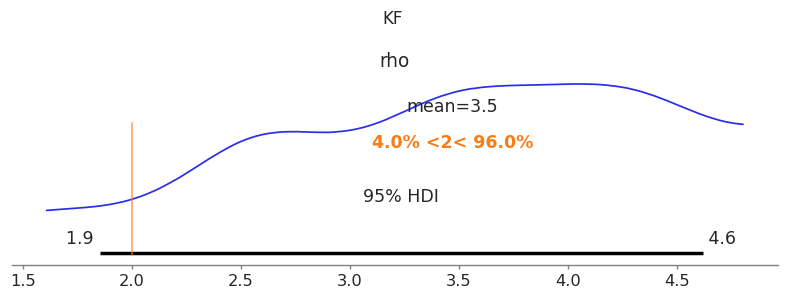

/var/folders/28/rfdjbzgj0bz_x56whkjmhl600000gn/T/ipykernel_95659/4074211388.py:114: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


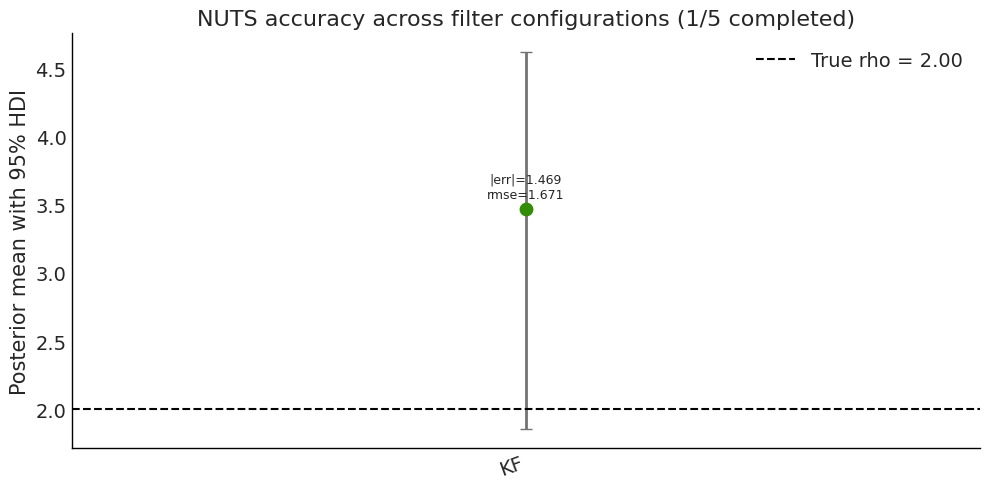

/var/folders/28/rfdjbzgj0bz_x56whkjmhl600000gn/T/ipykernel_95659/4074211388.py:132: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


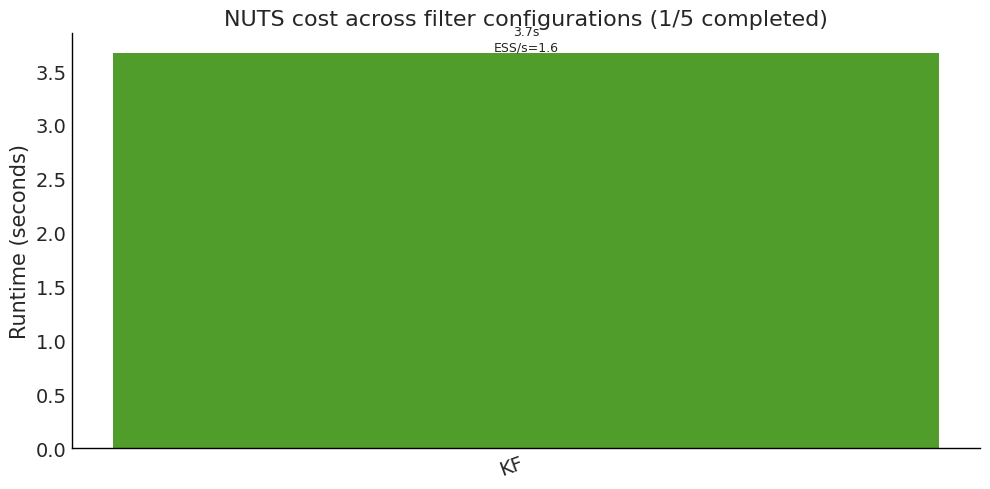

{'name': 'KF', 'runtime_seconds': 3.667384458996821, 'posterior_mean': 3.469409432264986, 'posterior_std': 0.7957581512621479, 'hdi_2_5': 1.852, 'hdi_97_5': 4.621, 'ess_bulk': 6.0, 'r_hat': nan, 'color': 'C2', 'abs_mean_error': 1.4694094322649862, 'rmse_to_truth': 1.6710461139446335, 'ess_bulk_per_second': 1.6360433619880812}
Running DPF 2500 · fixed key ...


arviz - WARNING - Shape validation failed: input_shape: (1, 50), minimum_shape: (chains=2, draws=4)


DPF 2500 · fixed key: runtime=6925.94s, mean=3.5543, std=0.7121, abs error=1.5543


/var/folders/28/rfdjbzgj0bz_x56whkjmhl600000gn/T/ipykernel_95659/4074211388.py:183: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


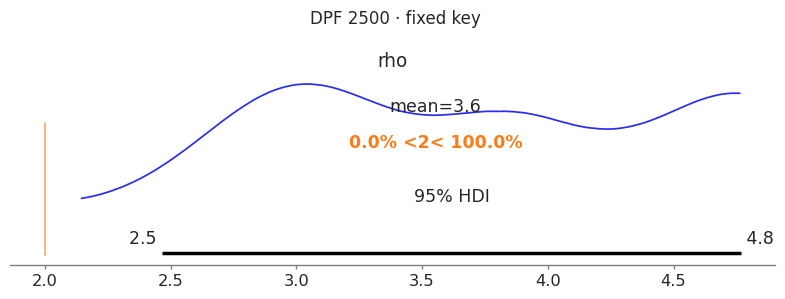

/var/folders/28/rfdjbzgj0bz_x56whkjmhl600000gn/T/ipykernel_95659/4074211388.py:114: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


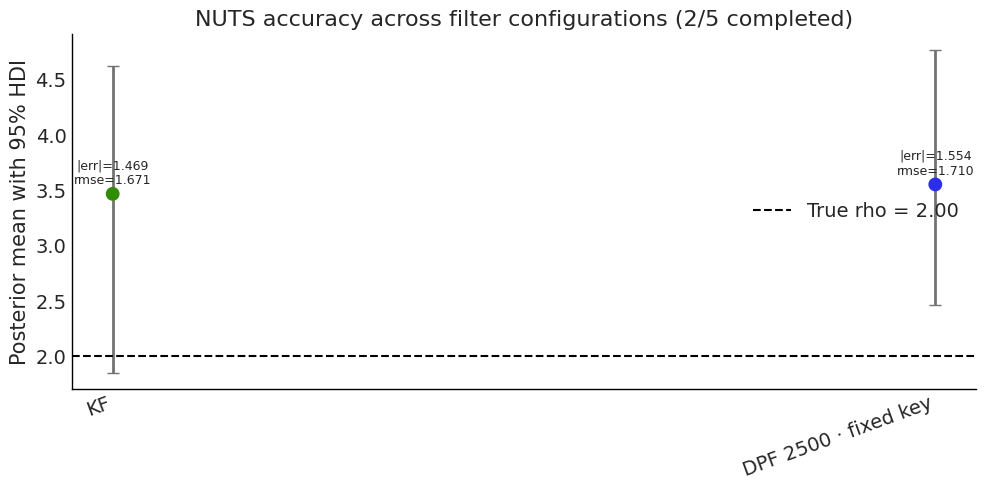

/var/folders/28/rfdjbzgj0bz_x56whkjmhl600000gn/T/ipykernel_95659/4074211388.py:132: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


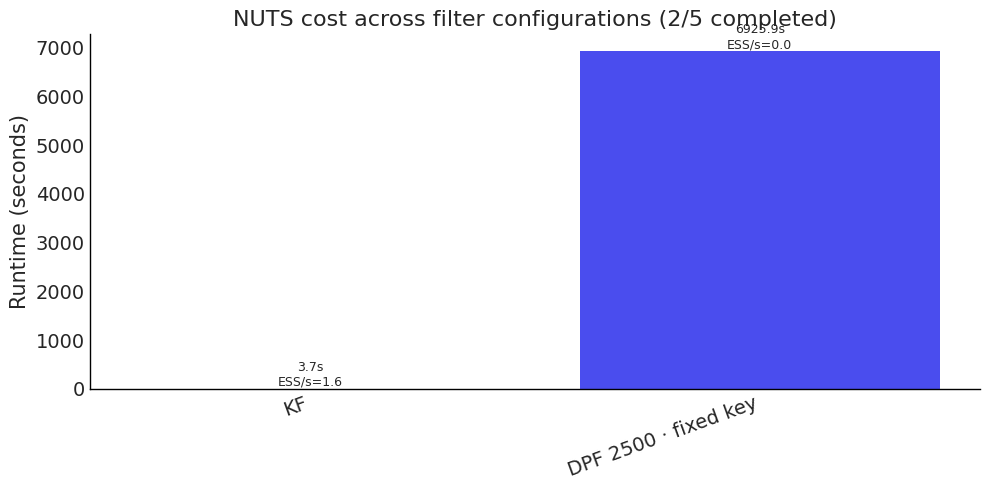

{'name': 'KF', 'runtime_seconds': 3.667384458996821, 'posterior_mean': 3.469409432264986, 'posterior_std': 0.7957581512621479, 'hdi_2_5': 1.852, 'hdi_97_5': 4.621, 'ess_bulk': 6.0, 'r_hat': nan, 'color': 'C2', 'abs_mean_error': 1.4694094322649862, 'rmse_to_truth': 1.6710461139446335, 'ess_bulk_per_second': 1.6360433619880812}
{'name': 'DPF 2500 · fixed key', 'runtime_seconds': 6925.944903707947, 'posterior_mean': 3.554335976450555, 'posterior_std': 0.7121387867439337, 'hdi_2_5': 2.468, 'hdi_97_5': 4.766, 'ess_bulk': 4.0, 'r_hat': nan, 'color': 'C0', 'abs_mean_error': 1.554335976450555, 'rmse_to_truth': 1.7097081561698249, 'ess_bulk_per_second': 0.0005775385244341921}
Running DPF 250 · fixed key ...


arviz - WARNING - Shape validation failed: input_shape: (1, 50), minimum_shape: (chains=2, draws=4)


DPF 250 · fixed key: runtime=57819.95s, mean=2.6771, std=0.0013, abs error=0.6771


/var/folders/28/rfdjbzgj0bz_x56whkjmhl600000gn/T/ipykernel_95659/4074211388.py:183: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


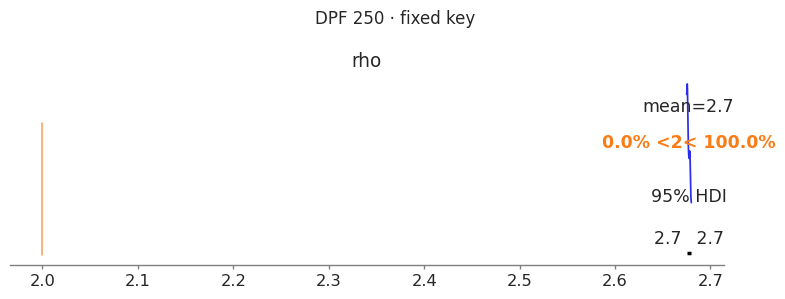

/var/folders/28/rfdjbzgj0bz_x56whkjmhl600000gn/T/ipykernel_95659/4074211388.py:114: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


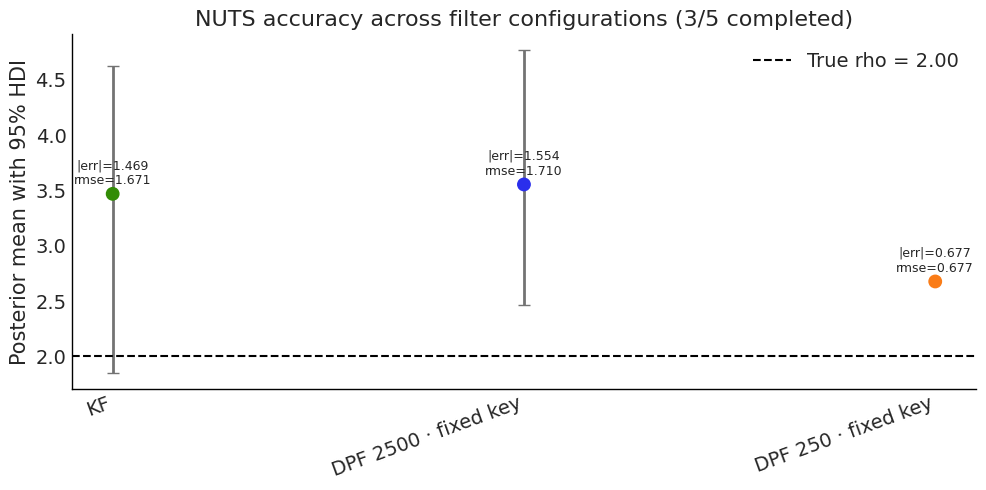

/var/folders/28/rfdjbzgj0bz_x56whkjmhl600000gn/T/ipykernel_95659/4074211388.py:132: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


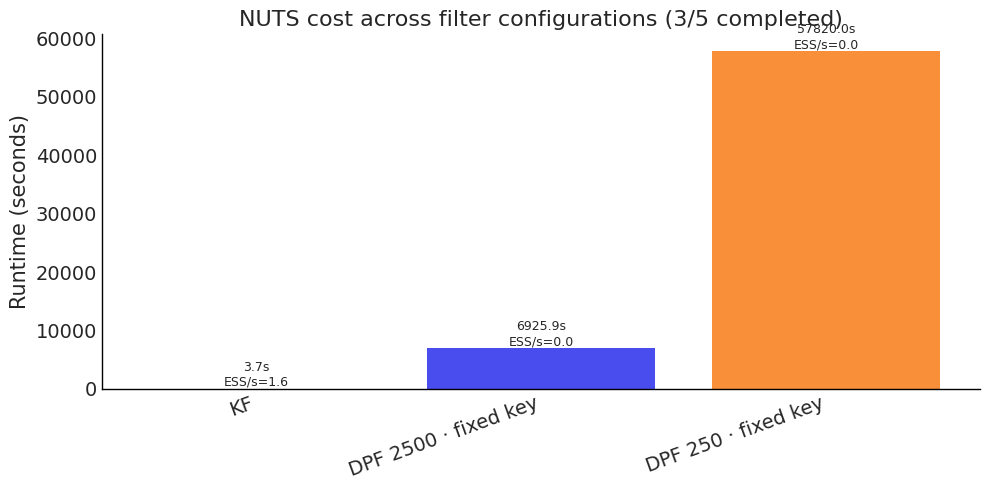

{'name': 'KF', 'runtime_seconds': 3.667384458996821, 'posterior_mean': 3.469409432264986, 'posterior_std': 0.7957581512621479, 'hdi_2_5': 1.852, 'hdi_97_5': 4.621, 'ess_bulk': 6.0, 'r_hat': nan, 'color': 'C2', 'abs_mean_error': 1.4694094322649862, 'rmse_to_truth': 1.6710461139446335, 'ess_bulk_per_second': 1.6360433619880812}
{'name': 'DPF 2500 · fixed key', 'runtime_seconds': 6925.944903707947, 'posterior_mean': 3.554335976450555, 'posterior_std': 0.7121387867439337, 'hdi_2_5': 2.468, 'hdi_97_5': 4.766, 'ess_bulk': 4.0, 'r_hat': nan, 'color': 'C0', 'abs_mean_error': 1.554335976450555, 'rmse_to_truth': 1.7097081561698249, 'ess_bulk_per_second': 0.0005775385244341921}
{'name': 'DPF 250 · fixed key', 'runtime_seconds': 57819.95492012502, 'posterior_mean': 2.6770844970495062, 'posterior_std': 0.0013437531518894637, 'hdi_2_5': 2.675, 'hdi_97_5': 2.679, 'ess_bulk': 1.0, 'r_hat': nan, 'color': 'C1', 'abs_mean_error': 0.6770844970495062, 'rmse_to_truth': 0.677085830465618, 'ess_bulk_per_secon

In [ ]:
az.style.use("arviz-white")

# Keep these explicit so this cell can be rerun by hand without rerunning the profile section.
profile_particles = 250
large_profile_particles = 2500
num_warmup = 50
num_samples = 50
true_rho_value = float(true_rho)

nuts_experiments = [
    {
        "name": "KF",
        "logdensity_fn": make_blackjax_logdensity(obs_times, obs_values, filter_name="kf"),
        "seed": 101,
        "color": "C2",
    },
    {
        "name": "DPF 2500 · fixed key",
        "logdensity_fn": make_blackjax_logdensity(
            obs_times,
            obs_values,
            filter_name="pf",
            n_particles=large_profile_particles,
            fixed_key=jr.PRNGKey(0),
            key_mode="fixed",
        ),
        "seed": 103,
        "color": "C0",
    },
    {
        "name": "DPF 250 · fixed key",
        "logdensity_fn": make_blackjax_logdensity(
            obs_times,
            obs_values,
            filter_name="pf",
            n_particles=profile_particles,
            fixed_key=jr.PRNGKey(0),
            key_mode="fixed",
        ),
        "seed": 102,
        "color": "C1",
    },
    {
        "name": "DPF 250 · no fixed key",
        "logdensity_fn": make_blackjax_logdensity(
            obs_times,
            obs_values,
            filter_name="pf",
            n_particles=profile_particles,
            fixed_key=jr.PRNGKey(1),
            key_mode="hashed_position",
        ),
        "seed": 104,
        "color": "C1",
    },
    {
        "name": "DPF 2500 · no fixed key",
        "logdensity_fn": make_blackjax_logdensity(
            obs_times,
            obs_values,
            filter_name="pf",
            n_particles=large_profile_particles,
            fixed_key=jr.PRNGKey(2),
            key_mode="hashed_position",
        ),
        "seed": 105,
        "color": "C0",
    },
]

nuts_results = []
nuts_inference_data = {}


def _plot_running_nuts_comparison(results):
    names = [result["name"] for result in results]
    posterior_means = np.array([result["posterior_mean"] for result in results])
    hdi_lows = np.array([result["hdi_2_5"] for result in results])
    hdi_highs = np.array([result["hdi_97_5"] for result in results])
    abs_errors = np.array([result["abs_mean_error"] for result in results])
    rmse_values = np.array([result["rmse_to_truth"] for result in results])
    runtime_seconds = np.array([result["runtime_seconds"] for result in results])
    ess_per_second = np.array([result["ess_bulk_per_second"] for result in results])
    colors = [result["color"] for result in results]
    x = np.arange(len(names))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.errorbar(
        x,
        posterior_means,
        yerr=np.vstack([posterior_means - hdi_lows, hdi_highs - posterior_means]),
        fmt="o",
        color="0.15",
        ecolor="0.45",
        elinewidth=2,
        capsize=4,
    )
    ax.scatter(x, posterior_means, s=80, c=colors, zorder=3)
    ax.axhline(true_rho_value, color="black", linestyle="--", linewidth=1.5, label=f"True rho = {true_rho_value:.2f}")
    for idx, error in enumerate(abs_errors):
        ax.text(
            idx,
            posterior_means[idx] + 0.06,
            f"|err|={error:.3f}\nrmse={rmse_values[idx]:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=20, ha="right")
    ax.set_ylabel("Posterior mean with 95% HDI")
    ax.set_title(f"NUTS accuracy across filter configurations ({len(results)}/{len(nuts_experiments)} completed)")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(x, runtime_seconds, color=colors, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=20, ha="right")
    ax.set_ylabel("Runtime (seconds)")
    ax.set_title(f"NUTS cost across filter configurations ({len(results)}/{len(nuts_experiments)} completed)")
    for idx, bar in enumerate(bars):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{runtime_seconds[idx]:.1f}s\nESS/s={ess_per_second[idx]:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )
    plt.tight_layout()
    plt.show()


for experiment in nuts_experiments:
    print(f"Running {experiment['name']} ...")
    t0 = time.perf_counter()
    run = run_blackjax_nuts_1d(
        experiment["logdensity_fn"],
        experiment["seed"],
        init_position=2.5,
        num_warmup=num_warmup,
        num_samples=num_samples,
    )
    elapsed_seconds = time.perf_counter() - t0

    posterior_rho = np.asarray(run["samples"])
    inference_data = az.from_dict(posterior={"rho": posterior_rho[None, :]})
    summary = az.summary(inference_data, var_names=["rho"], hdi_prob=0.95)
    rho_summary = summary.loc["rho"]

    result = {
        "name": experiment["name"],
        "runtime_seconds": elapsed_seconds,
        "posterior_mean": float(posterior_rho.mean()),
        "posterior_std": float(posterior_rho.std()),
        "hdi_2_5": float(rho_summary["hdi_2.5%"]),
        "hdi_97_5": float(rho_summary["hdi_97.5%"]),
        "ess_bulk": float(rho_summary["ess_bulk"]),
        "r_hat": float(rho_summary["r_hat"]),
        "color": experiment["color"],
    }
    result["abs_mean_error"] = abs(result["posterior_mean"] - true_rho_value)
    result["rmse_to_truth"] = float(np.sqrt(np.mean((posterior_rho - true_rho_value) ** 2)))
    result["ess_bulk_per_second"] = result["ess_bulk"] / max(result["runtime_seconds"], 1e-9)
    nuts_results.append(result)
    nuts_inference_data[experiment["name"]] = inference_data

    print(
        f"{experiment['name']}: runtime={elapsed_seconds:.2f}s, "
        f"mean={result['posterior_mean']:.4f}, std={result['posterior_std']:.4f}, "
        f"abs error={result['abs_mean_error']:.4f}"
    )
    az.plot_posterior(
        inference_data,
        var_names=["rho"],
        hdi_prob=0.95,
        ref_val=true_rho_value,
        figsize=(8, 3),
    )
    plt.suptitle(experiment["name"])
    plt.tight_layout()
    plt.show()

    _plot_running_nuts_comparison(nuts_results)

    results_by_name = {result["name"]: result for result in nuts_results}
    for result in nuts_results:
        print(result)


## Summary

This notebook reproduces the same LTI Gaussian profile-likelihood and NUTS workflow as the dynestyx example, but the simulator, exact KF, bootstrap PF, and NUTS driver are all coded directly in local source files. In the low-level setting, the `2500`-particle DPF profile band is the cleanest self-contained visual anchor, while the `250`-particle lines remain in the figure to show the rougher stochastic regime.
